In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

In [2]:
df = data.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.shape

(6468, 24)

In [3]:
df.isnull().sum()

Gold_Open       0
Gold_High       0
Gold_Low        0
Gold_Close      0
Gold_Volume     0
DXY             0
SP500           0
Oil             0
VIX             0
Lag1            0
Lag7            0
MA7             0
MA30            0
EMA20           0
Daily_Return    0
RSI             0
MACD            0
MACD_Signal     0
MACD_Hist       0
BB_Upper        0
BB_Middle       0
BB_Lower        0
ATR             0
Target          0
dtype: int64

In [4]:
# day-of-week / month seasonality, added straight to df so the latest row already has everything it needs later
dow = df.index.dayofweek
df["dow_sin"] = np.sin(2*np.pi*dow/7)
df["dow_cos"] = np.cos(2*np.pi*dow/7)

month = df.index.month
df["month_sin"] = np.sin(2*np.pi*month/12)
df["month_cos"] = np.cos(2*np.pi*month/12)

print(df.shape)

(6468, 28)


In [5]:
df[["Gold_Close","RSI","MACD","DXY","VIX"]].tail()

,Gold_Close,RSI,MACD,DXY,VIX
Date,,,,,
2026-07-24,4067.600098,45.939508,-51.155755,101.470001,18.580000
2026-07-27,4074.500000,46.480858,-46.768670,101.510002,18.670000
2026-07-28,4036.300049,43.862116,-45.845807,101.379997,18.209999
2026-07-29,4034.699951,43.750924,-44.727951,100.800003,20.660000
2026-07-30,4100.100098,49.397363,-38.125311,100.010002,17.090000


In [6]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos'],
      dtype='str')

In [7]:
HORIZON = 21  # ~1 trading month ahead (21 trading days)
df['Target_Direct'] = df["Gold_Close"].shift(-HORIZON)
df = df.dropna(subset=['Target', 'Target_Direct'])

X = df.drop(columns=['Target', 'Target_Direct'])

y_Recursive = df['Target']      # tomorrow's Close
y_Direct = df['Target_Direct']  # Close after 21 days

In [8]:
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.80)   # 70% train + 10% validation

# X split
X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

# Recursive target split
y_r_train = y_Recursive.iloc[:train_end]
y_r_val   = y_Recursive.iloc[train_end:val_end]
y_r_test  = y_Recursive.iloc[val_end:]

# Direct target split
y_d_train = y_Direct.iloc[:train_end]
y_d_val   = y_Direct.iloc[train_end:val_end]
y_d_test  = y_Direct.iloc[val_end:]

# Test dates
dates_test = df.index[val_end:]

print("x Train:", X_train.shape)
print("x Validation:", X_val.shape)
print("x Test:", X_test.shape)

print("\nRecursive:")
print("y Train:", y_r_train.shape)
print("y Validation:", y_r_val.shape)
print("y Test:", y_r_test.shape)

print("\nDirect:")
print("y Train:", y_d_train.shape)
print("y Validation:", y_d_val.shape)
print("y Test:", y_d_test.shape)

x Train: (4512, 27)
x Validation: (645, 27)
x Test: (1290, 27)

Recursive:
y Train: (4512,)
y Validation: (645,)
y Test: (1290,)

Direct:
y Train: (4512,)
y Validation: (645,)
y Test: (1290,)


In [9]:
from sklearn.preprocessing import StandardScaler

# 1. Scale X
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

# 2. Scale Recursive Target
scaler_y_r = StandardScaler()

y_r_train_s = scaler_y_r.fit_transform(y_r_train.values.reshape(-1, 1)).ravel()
y_r_val_s = scaler_y_r.transform(y_r_val.values.reshape(-1, 1)).ravel()
y_r_test_s = scaler_y_r.transform(y_r_test.values.reshape(-1, 1)).ravel()

# 3. Scale Direct Target
scaler_y_d = StandardScaler()

y_d_train_s = scaler_y_d.fit_transform(y_d_train.values.reshape(-1, 1)).ravel()
y_d_val_s = scaler_y_d.transform(y_d_val.values.reshape(-1, 1)).ravel()
y_d_test_s = scaler_y_d.transform(y_d_test.values.reshape(-1, 1)).ravel()

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Recursive Baselines
naive_recursive_pred = X_test["Gold_Close"].values
linreg_recursive = LinearRegression()
linreg_recursive.fit(X_train_s,y_r_train_s)

linreg_recursive_pred_s = linreg_recursive.predict(X_test_s)
linreg_recursive_pred = scaler_y_r.inverse_transform(linreg_recursive_pred_s.reshape(-1, 1)).ravel()

def evaluate_baseline(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(
        f"{label:35s}"
        f"MAE={mae:8.3f}  "
        f"RMSE={rmse:8.3f}  "
        f"R²={r2:7.4f}"
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

recursive_baseline_results = {}

recursive_baseline_results["naive"] = evaluate_baseline(y_r_test.values, naive_recursive_pred, "Recursive Naive Baseline")
recursive_baseline_results["linreg"] = evaluate_baseline(y_r_test.values, linreg_recursive_pred, "Recursive Linear Regression")

# Direct Baselines --------------------------------------------

naive_direct_pred = X_test["Gold_Close"].values
linreg_direct = LinearRegression()
linreg_direct.fit(X_train_s,y_d_train_s)

linreg_direct_pred_s = linreg_direct.predict(X_test_s)
linreg_direct_pred = scaler_y_d.inverse_transform(linreg_direct_pred_s.reshape(-1, 1)).ravel()

direct_baseline_results = {}

direct_baseline_results["naive"] = evaluate_baseline(y_d_test.values, naive_direct_pred, "Direct Naive Baseline")
direct_baseline_results["linreg"] = evaluate_baseline(y_d_test.values, linreg_direct_pred, "Direct Linear Regression")

Recursive Naive Baseline           MAE=  23.170  RMSE=  41.214  R²= 0.9981
Recursive Linear Regression        MAE=  23.818  RMSE=  41.574  R²= 0.9981
Direct Naive Baseline              MAE= 107.302  RMSE= 162.796  R²= 0.9720
Direct Linear Regression           MAE= 131.907  RMSE= 193.157  R²= 0.9605


In [10]:
from GoldPricePredictor import GoldPricePredictor

predictor = GoldPricePredictor()

In [11]:
predictor.train_recursive(
    X_train=X_train_s,
    y_train=y_r_train_s,
    X_val=X_val_s,
    y_val=y_r_val_s,
    epochs=300,
    batch_size=32,
    tune_epochs=80,
    tune_patience=10,
    patience=20
)

--------- Training Recursive Model --------------

Config 0: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001} -> val_mae=0.1278
Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001} -> val_mae=0.1542
Config 2: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.001, 'lr': 0.0005} -> val_mae=0.2094
Config 3: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001} -> val_mae=0.0403

Best config:
{'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001}
Epoch 1/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5538 - mae: 0.1908 - mse: 0.0708 - val_loss: 1.1868 - val_mae: 0.4409 - val_mse: 0.2279 - learning_rate: 0.0010
Epoch 2/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5862 - mae: 0.1206 - mse: 0.0263 - val_loss: 0.42

In [12]:
predictor.train_direct(
    X_train=X_train_s,
    y_train=y_d_train_s,
    X_val=X_val_s,
    y_val=y_d_val_s,
    epochs=300,
    batch_size=32,
    tune_epochs=80,
    tune_patience=10,
    patience=20
)

 ------------ Training Direct Model---------- 
Config 0: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001} -> val_mae=0.2337
Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001} -> val_mae=0.3188
Config 2: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.001, 'lr': 0.0005} -> val_mae=0.2361
Config 3: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001} -> val_mae=0.1752

Best config:
{'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001}
Epoch 1/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5442 - mae: 0.2172 - mse: 0.0960 - val_loss: 0.9802 - val_mae: 0.2649 - val_mse: 0.0988 - learning_rate: 0.0010
Epoch 2/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5907 - mae: 0.1447 - mse: 0.0356 - val_loss: 0.5673 -


Recursive Model Results
RMSE : 0.111
MAE  : 0.069
R²   : 0.9972


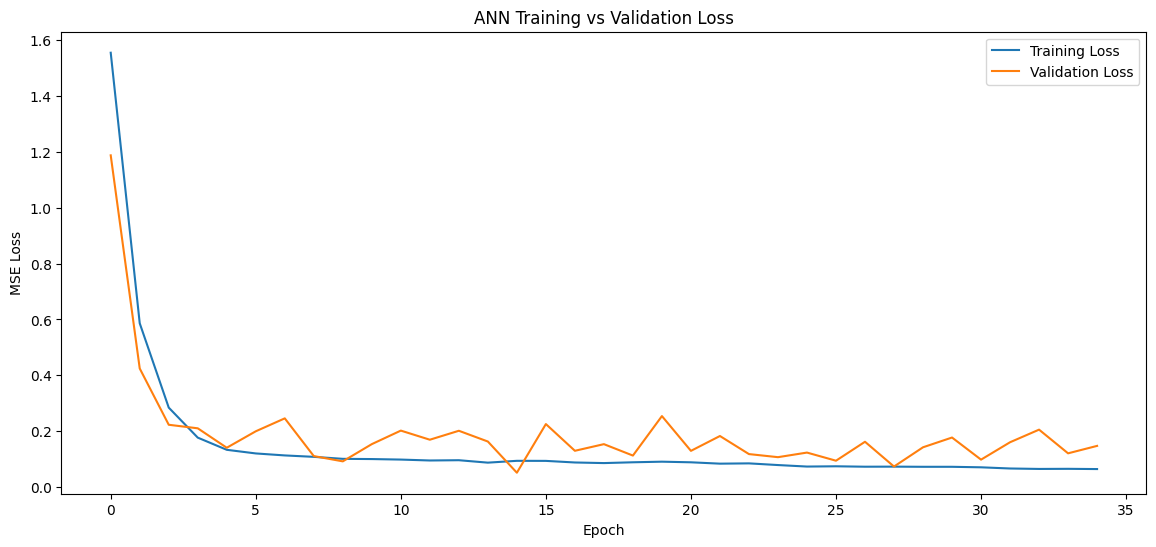

In [13]:
recursive_scaled_results = predictor.evaluate_recursive(
    X_test=X_test_s,
    y_test=y_r_test_s
)


Direct Model Results
RMSE : 0.777
MAE  : 0.619
R²   : 0.8691


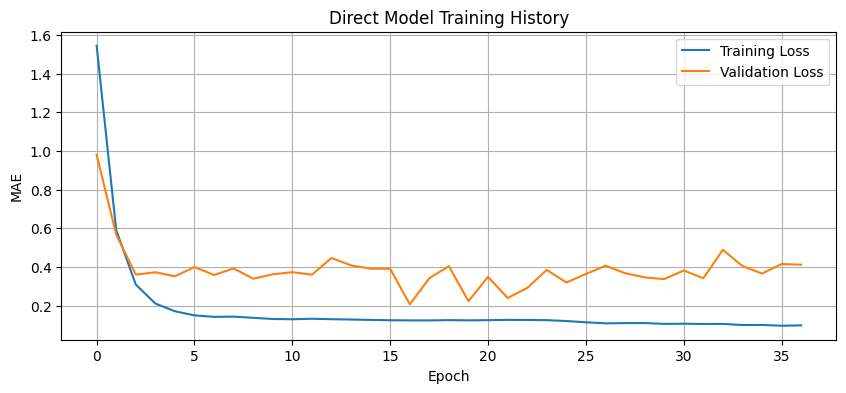

In [14]:
direct_scaled_results = predictor.evaluate_direct(
    X_test=X_test_s,
    y_test=y_d_test_s
)